In [41]:
import cufflinks as cf
import pandas as pd
import numpy as np
cf.go_offline(connected=True)
cf.set_config_file(colorscale='plotly', world_readable=True)

# Extra options
pd.options.display.max_rows = 30
pd.options.display.max_columns = 25

# Show all code cells outputs
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = 'all'

In [42]:
df = pd.DataFrame(np.random.random(10).reshape(5, 2)).rename(columns={0: "A", 1: "B"})
df['C'] = ['a', 'b', 'c', 'd', 'e'] 
df

,A,B,C
0,0.452822,0.798443,a
1,0.735794,0.744530,b
2,0.734659,0.067560,c
3,0.373476,0.352266,d
4,0.150820,0.747237,e


In [35]:
import ipywidgets as widgets
from ipywidgets import interact, interact_manual, HTML

In [36]:
@interact
def show_1(column='A', x=0.5):
    display(HTML(f'<h2>Showing df with more than {x} {column}<h2>'))
    display(df.loc[df[column] > x, ['A', 'B', 'C']])

HTML(value='<h2>Showing df with more than 0.5 A<h2>')

,A,B,C
2,0.805857,0.155632,c
3,0.888174,0.674475,d
4,0.687392,0.405212,e


In [37]:
@interact
def show_2(x=(0.1, 1, 0.1), column=list(df.select_dtypes('number').columns)):
    display(df.loc[df[column] > x, ['A', 'B', 'C']])

,A,B,C
2,0.805857,0.155632,c
3,0.888174,0.674475,d
4,0.687392,0.405212,e


In [38]:
@interact
def correlations(column1=list(df.select_dtypes('number').columns), 
                 column2=list(df.select_dtypes('number').columns)):
    print(f"Correlation: {df[column1].corr(df[column2])}")

Correlation: 0.9999999999999998


In [39]:
@interact
def describe(column=list(df.columns)):
    print(df[column].describe())

count    5.000000
mean     0.583203
std      0.297083
min      0.266222
25%      0.268370
50%      0.687392
75%      0.805857
max      0.888174
Name: A, dtype: float64


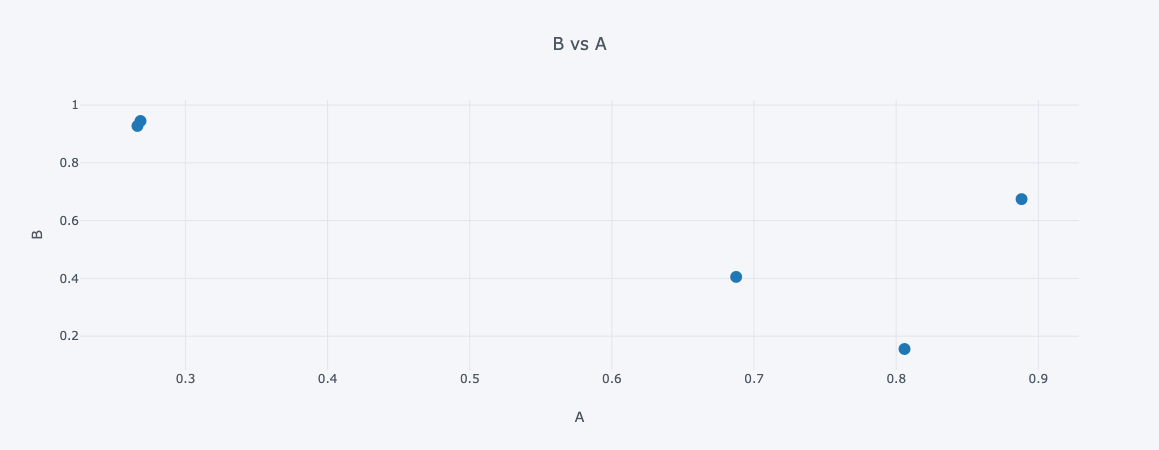

In [40]:
@interact
def scatter_plot(x=list(df.select_dtypes('number').columns), 
                 y=list(df.select_dtypes('number').columns)[1:]):
    df.iplot(kind='scatter', x=x, y=y, mode='markers', xTitle=x.title(), yTitle=y.title(), title=f'{y.title()} vs {x.title()}')